In [1]:
import psutil
print(psutil.virtual_memory())

svmem(total=17179869184, available=7632814080, percent=55.6, used=7182614528, free=2248753152, active=5269913600, inactive=5351145472, wired=1912700928)


In [2]:
# Data handling
import numpy as np
import pandas as pd

# Machine Learning - Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Oversampling
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    fbeta_score,
    cohen_kappa_score,
    matthews_corrcoef
)

In [3]:
%matplotlib inline

In [4]:
data = pd.read_csv('../data/creditcard.csv')

In [5]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
data.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Train test and split

In [11]:
# Min-max normalization
numeric_features = data.dtypes[data.dtypes != 'object'].index
data[numeric_features] = data[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max()-x.min()))
# Fill empty values by 0
data = data.fillna(0)

In [12]:
labelencoder = LabelEncoder()
data.iloc[:, -1] = labelencoder.fit_transform(data.iloc[:, -1])
#X = data.drop([' Label'], axis=1).values
#Y = data.iloc[:, -1].values.reshape(-1,1)
#Y = np.ravel(Y)
X = data.drop('Class', axis=1)
Y = data['Class']
Y = labelencoder.fit_transform(Y)  # Ensure consistent encoding
print("Encoded classes:", labelencoder.classes_)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y)

Encoded classes: [0. 1.]


In [13]:
X_train.shape

(227845, 30)

In [14]:
Y_test.shape

(56962,)

In [15]:
pd.Series(Y_train).value_counts()

0    227451
1       394
Name: count, dtype: int64

Calculating the correlation matrix...
Correlation Matrix (preview):
          Time            V1            V2            V3            V4  \
Time  1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1    0.117396  1.000000e+00  1.746106e-14  1.027566e-13  1.486596e-14   
V2   -0.010593  1.746106e-14  1.000000e+00 -7.599107e-14 -1.710874e-14   
V3   -0.419618  1.027566e-13 -7.599107e-14  1.000000e+00  1.237002e-14   
V4   -0.105260  1.486596e-14 -1.710874e-14  1.237002e-14  1.000000e+00   

                V5            V6            V7            V8            V9  \
Time  1.730721e-01 -6.301647e-02  8.471437e-02 -3.694943e-02 -8.660434e-03   
V1    5.920763e-14  1.705832e-14 -3.063624e-14  5.470123e-15 -2.111352e-14   
V2    3.867793e-14 -5.417328e-15  1.133256e-14 -1.572443e-14 -5.282469e-15   
V3   -3.179412e-13 -9.050933e-15  5.412571e-14  3.602720e-15  2.920132e-14   
V4   -9.365645e-14  2.673617e-15  5.851469e-15 -5.392357e-16  3.331727e-15   

      ...         

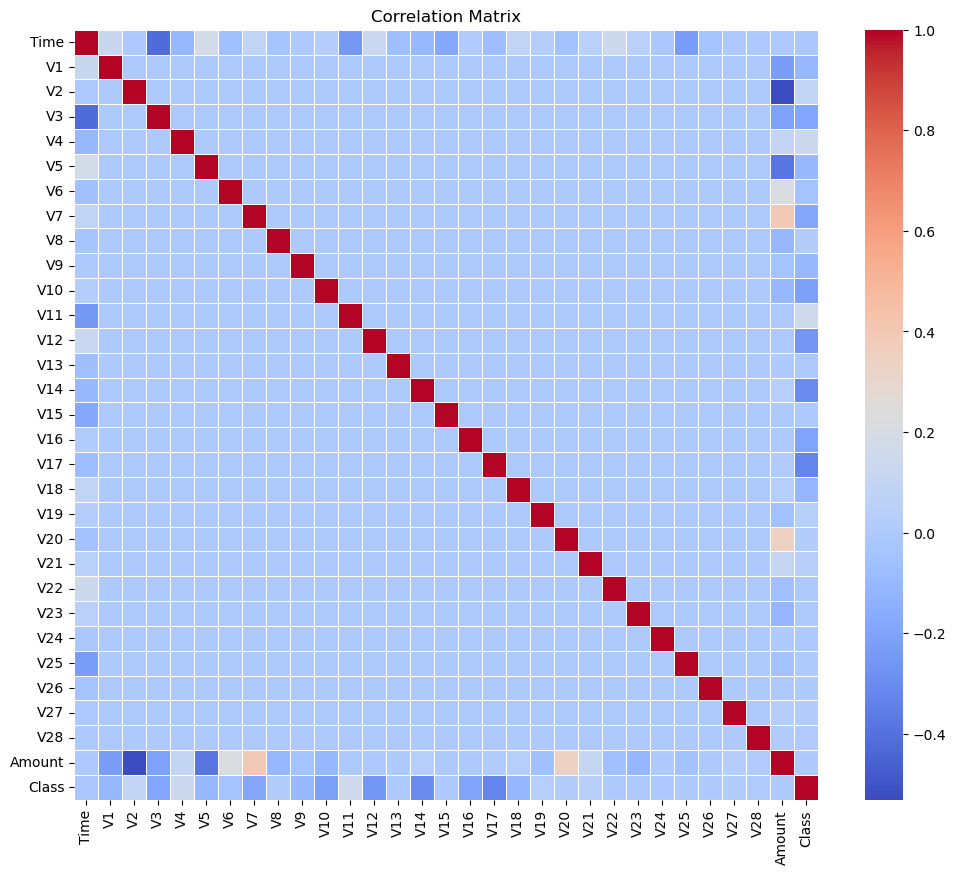

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
print("Calculating the correlation matrix...")
correlation_matrix = data.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Visualize the correlation matrix with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Correlation with the target variable:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


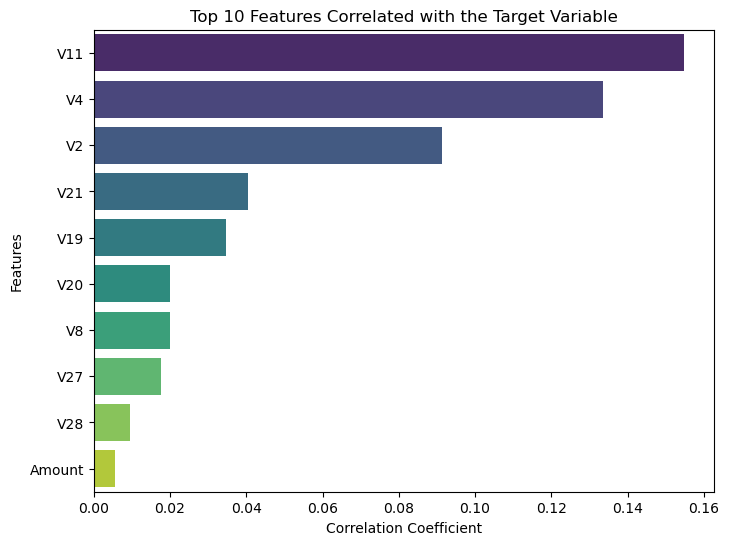

In [17]:
# Analyze correlation with the target variable ("Class")
if 'Class' in correlation_matrix.columns:
    target_corr = correlation_matrix['Class'].sort_values(ascending=False)
    print("Correlation with the target variable:")
    print(target_corr)

    # Visualize the strongest correlations with the target variable
    top_features = target_corr[1:11]  # Exclude correlation with itself
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
    plt.title('Top 10 Features Correlated with the Target Variable')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.show()
else:
    print("The 'Class' column does not exist in the dataset.")

In [18]:
# Check the range of correlation values
max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# Lower the threshold for moderate correlations
threshold = 0.8  # Adjust to a lower value
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

Strongly correlated features (>|0.8|):


In [19]:
#smote = SMOTE()
print(type(Y))
print(Y.dtype)
print(np.unique(Y))
pd.Series(Y_train).value_counts()

<class 'numpy.ndarray'>
int64
[0 1]


0    227451
1       394
Name: count, dtype: int64

# Outliers removal

In [20]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import shapiro
from sklearn.ensemble import IsolationForest


def check_outliers(X, Y, threshold=3, iqr_factor=1.5):
    """
    Check if outliers exist in the dataset (X and Y) using Z-score or IQR.
    Returns True if outliers are detected in either X or Y, False otherwise.
    """
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    
    # Ensure Y is a pandas Series
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)
    
    # Filter only numeric columns for X
    X_numeric = X_normal.select_dtypes(include=['number'])
    
    # Calculate Z-scores for X and Y
    z_scores_X = np.abs(stats.zscore(X_numeric))
    z_scores_Y = np.abs(stats.zscore(Y_normal))
    
    outliers_zscore_X = (z_scores_X > threshold).any().any()
    outliers_zscore_Y = (z_scores_Y > threshold).any()
    
    # Calculate IQR for X and Y
    Q1_X = X_numeric.quantile(0.25)
    Q3_X = X_numeric.quantile(0.75)
    IQR_X = Q3_X - Q1_X
    
    Q1_Y = Y.quantile(0.25)
    Q3_Y = Y.quantile(0.75)
    IQR_Y = Q3_Y - Q1_Y
    
    outliers_iqr_X = ((X_numeric < (Q1_X - iqr_factor * IQR_X)) | (X_numeric > (Q3_X + iqr_factor * IQR_X))).any().any()
    outliers_iqr_Y = ((Y_normal < (Q1_Y - iqr_factor * IQR_Y)) | (Y_normal > (Q3_Y + iqr_factor * IQR_Y))).any()
    
    return outliers_zscore_X or outliers_zscore_Y or outliers_iqr_X or outliers_iqr_Y
    
def remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5):
    """
    Removes outliers from normal transactions only.
    """

    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    X_fraud = X[Y == 1]
    Y_fraud = Y[Y == 1]

    # Outlier removal
    if method == "auto":
        print("Automatically selecting outlier removal method...")
        if X_normal.std().mean() < threshold:
            print("Using Z-score for outlier removal...")
            X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)
        else:
            print("Using IQR for outlier removal...")
            X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
            Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "zscore":
        print("Using Z-score for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)

    elif method == "iqr":
        print("Using IQR for outlier removal...")
        X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
        Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "isolation_forest":
        print("Using Isolation Forest for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_if(X_normal, Y_normal)

    # Reunify data
    X_cleaned = pd.concat([X_normal_cleaned, X_fraud], axis=0).sort_index()
    Y_cleaned = pd.concat([Y_normal_cleaned, Y_fraud], axis=0).sort_index()

    return X_cleaned, Y_cleaned

def remove_outliers_using_zscore(X, Y, threshold):
    """
    Removes outliers using the Z-score method.
    """
    z_scores = np.abs(stats.zscore(X))
    X_filtered = X[(z_scores < threshold).all(axis=1)]
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

def remove_outliers_using_iqr(X, iqr_factor=1.5):
    """
    Removes outliers using the IQR method.
    """
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    return X[~((X < (Q1 - iqr_factor * IQR)) | (X > (Q3 + iqr_factor * IQR))).any(axis=1)].copy()

def remove_outliers_using_if(X, Y, contamination=0.05):
    """
    Removes outliers using Isolation Forest.
    """
    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(X)
    X_filtered = X[preds != -1]  # IsolationForest marks outliers as -1
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

# Example usage:
# X_cleaned, Y_cleaned = remove_outliers(X, Y, method="auto")

In [ ]:
# Assuming X is your DataFrame (features) and Y is your Series (target)
outliers_exist = check_outliers(X, Y)
print(f"Outliers detected: {outliers_exist}")

# Step 2: Remove outliers if they exist
if outliers_exist:
    X_filtered, y_filtered = remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=2.0)
    print("Outliers removed.")
else:
    print("No outliers detected. Data is clean.")

print("Cleaned Features (X):")
print(X_filtered)
print("\nCleaned Target (Y):")
print(y_filtered)

Outliers detected: True
Automatically selecting outlier removal method...
Using Z-score for outlier removal...
Outliers removed.
Cleaned Features (X):
            Time        V1        V2        V3        V4        V5        V6  \
0       0.000000  0.935192  0.766490  0.881365  0.313023  0.763439  0.267669   
1       0.000000  0.978542  0.770067  0.840298  0.271796  0.766120  0.262192   
3       0.000006  0.941878  0.765304  0.868484  0.213661  0.765647  0.275559   
4       0.000012  0.938617  0.776520  0.864251  0.269796  0.762975  0.263984   
5       0.000012  0.951057  0.777393  0.857187  0.244472  0.768550  0.262721   
...          ...       ...       ...       ...       ...       ...       ...   
284800  0.999954  0.992943  0.765409  0.816674  0.262329  0.765658  0.255715   
284801  0.999959  0.960338  0.777082  0.827952  0.218901  0.773326  0.260647   
284803  0.999971  0.945845  0.766677  0.872678  0.219189  0.771561  0.273661   
284804  0.999977  0.990905  0.764080  0.781102  0

In [22]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Oversampling using RUS

In [23]:
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
#smote = SMOTE(sampling_strategy=0.8, random_state=42)
#print("Unique classes in Y:", np.unique(Y))
#print("Class distribution:\n", pd.Series(Y).value_counts())
# Apply SMOTE to balance the classes
#X_resampled, Y_resampled = smote.fit_resample(X_train, y_train)
#adasyn = ADASYN(random_state=42)
rus = RandomUnderSampler(random_state=42)
#X_rus, y_rus = rus.fit_resample(X_smote, y_smote)
X_resampled, Y_resampled = rus.fit_resample(X_train, y_train)
# Create a new DataFrame with the resampled data
data_resampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(Y_resampled, name='Class')], axis=1)

# Display the class distribution after SMOTE
class_distribution_after = Counter(data_resampled['Class'])
print("Class Distribution After RUS:", class_distribution_after)

Class Distribution After RUS: Counter({0: 399, 1: 399})


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, Y_resampled, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y_resampled)

Calculating the correlation matrix...
Correlation Matrix (preview):
          Time        V1        V2        V3        V4        V5        V6  \
Time  1.000000  0.244531 -0.223188  0.143400 -0.214480  0.286744  0.100047   
V1    0.244531  1.000000 -0.851011  0.894353 -0.646216  0.884055  0.338641   
V2   -0.223188 -0.851011  1.000000 -0.883203  0.713155 -0.821991 -0.300104   
V3    0.143400  0.894353 -0.883203  1.000000 -0.785158  0.859451  0.490619   
V4   -0.214480 -0.646216  0.713155 -0.785158  1.000000 -0.588571 -0.451669   

            V7        V8        V9  ...       V21       V22       V23  \
Time  0.214651 -0.153806  0.177723  ... -0.056731  0.130793  0.075001   
V1    0.901365 -0.093625  0.697055  ...  0.047592 -0.089308 -0.040425   
V2   -0.871833 -0.012773 -0.731283  ... -0.011575  0.054450  0.151138   
V3    0.895168 -0.170188  0.771124  ...  0.053059 -0.095806 -0.031349   
V4   -0.724296  0.088112 -0.791721  ... -0.035027  0.150100  0.020773   

           V24       V25

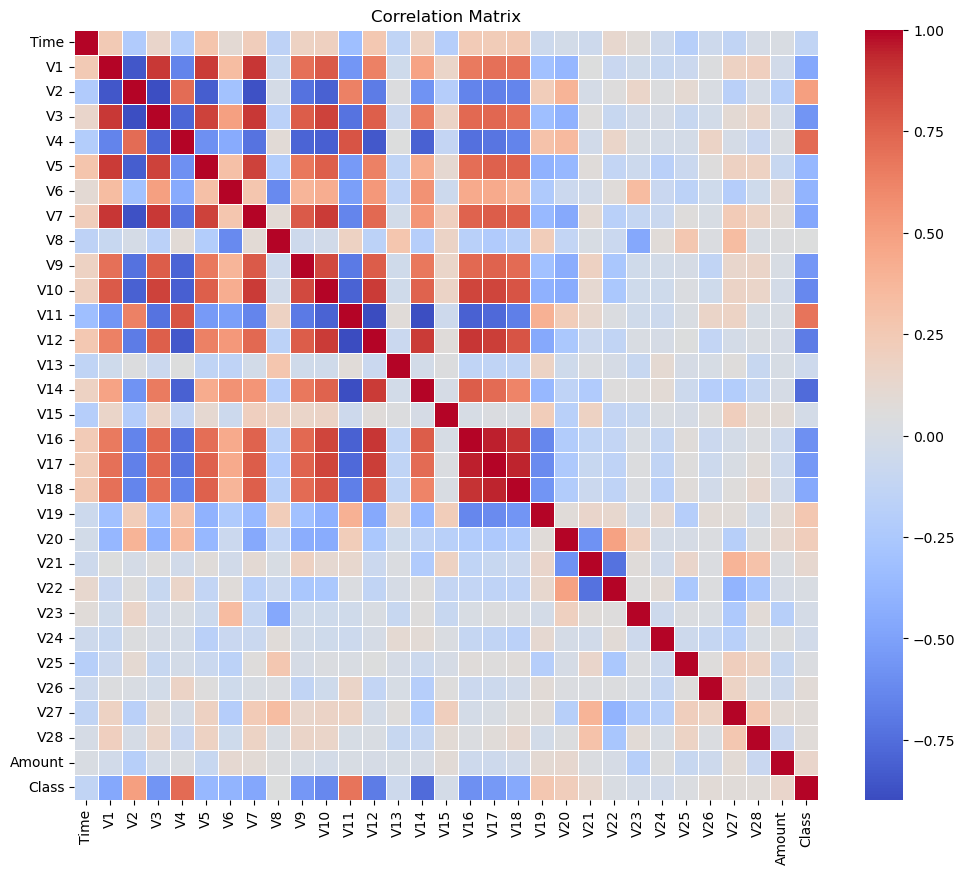

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
print("Calculating the correlation matrix...")
correlation_matrix = data_resampled.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Visualize the correlation matrix with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Correlation with the target variable:
Class     1.000000
V4        0.725015
V11       0.682084
V2        0.500645
V19       0.272599
V20       0.217093
Amount    0.147242
V21       0.120977
V26       0.082898
V28       0.079800
V27       0.077402
V8        0.049995
V25       0.034956
V22       0.021402
V23      -0.013303
V15      -0.022640
V24      -0.031679
V13      -0.059146
Time     -0.130406
V5       -0.369309
V6       -0.397809
V18      -0.456694
V1       -0.465962
V7       -0.472433
V17      -0.546073
V9       -0.552921
V3       -0.570164
V16      -0.593608
V10      -0.626809
V12      -0.685415
V14      -0.761165
Name: Class, dtype: float64


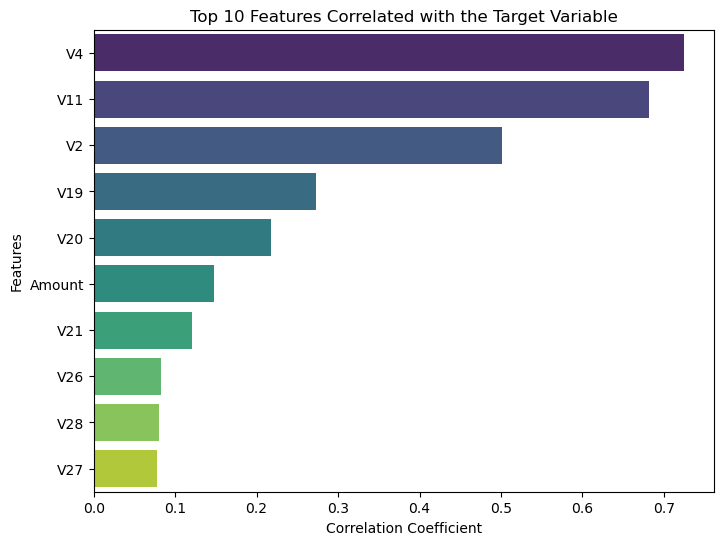

In [26]:
# Analyze correlation with the target variable ("Class")
if 'Class' in correlation_matrix.columns:
    target_corr = correlation_matrix['Class'].sort_values(ascending=False)
    print("Correlation with the target variable:")
    print(target_corr)

    # Visualize the strongest correlations with the target variable
    top_features = target_corr[1:11]  # Exclude correlation with itself
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
    plt.title('Top 10 Features Correlated with the Target Variable')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.show()
else:
    print("The 'Class' column does not exist in the dataset.")

In [27]:
# Check the range of correlation values
max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# Check for NaN values in the correlation matrix
#print("Number of NaN values in the correlation matrix:", correlation_matrix.isna().sum().sum())

# Lower the threshold for moderate correlations
threshold = 0.8  # Adjust to a lower value
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

Strongly correlated features (>|0.8|):
V2 and V1 : -0.85
V3 and V1 : 0.89
V3 and V2 : -0.88
V5 and V1 : 0.88
V5 and V2 : -0.82
V5 and V3 : 0.86
V7 and V1 : 0.90
V7 and V2 : -0.87
V7 and V3 : 0.90
V7 and V5 : 0.87
V10 and V2 : -0.81
V10 and V3 : 0.87
V10 and V4 : -0.81
V10 and V7 : 0.88
V10 and V9 : 0.84
V11 and V4 : 0.81
V11 and V10 : -0.80
V12 and V4 : -0.84
V12 and V10 : 0.89
V12 and V11 : -0.90
V14 and V4 : -0.81
V14 and V11 : -0.89
V14 and V12 : 0.88
V16 and V10 : 0.85
V16 and V11 : -0.80
V16 and V12 : 0.90
V17 and V10 : 0.85
V17 and V12 : 0.88
V17 and V16 : 0.95
V18 and V10 : 0.80
V18 and V12 : 0.81
V18 and V16 : 0.91
V18 and V17 : 0.95


# Feature importance

In [28]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50),
    #"CataBoost": CatBoostClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, algorithm='SAMME')
}

In [29]:
feature_importances = np.zeros(X_resampled.shape[1])
for name, model in models.items():
    # Train the model
    model.fit(X_resampled,Y_resampled)
    if hasattr(model, "feature_importances_"):
        #feature_importances = model.feature_importances_
        feature_importances += model.feature_importances_
        print(f"{name} Feature Importances:\n{model.feature_importances_}")
    else:
        print(f"{name} does not have feature_importances_ attribute.")

Decision Tree Feature Importances:
[0.         0.         0.         0.00345224 0.09728043 0.
 0.00406656 0.00764394 0.00501253 0.00559448 0.01621529 0.
 0.01160603 0.01676957 0.72108243 0.0274896  0.         0.
 0.         0.00687577 0.01395292 0.00345224 0.00567972 0.00932457
 0.         0.0060524  0.         0.         0.00837757 0.03007171]
Random Forest Feature Importances:
[0.00366586 0.01083101 0.04242481 0.0705383  0.10212831 0.00707825
 0.00854548 0.02082075 0.01410156 0.02130406 0.10025026 0.04407751
 0.10721461 0.00584385 0.21261836 0.00701835 0.03295674 0.08437291
 0.00745606 0.01039182 0.01172745 0.01886614 0.00430423 0.00904131
 0.00544824 0.00414659 0.00430655 0.01257573 0.00547374 0.01047115]
Extra Trees Feature Importances:
[0.0063052  0.02003657 0.02144233 0.05838833 0.10740886 0.01679529
 0.0207353  0.03851394 0.01227809 0.03671359 0.08484555 0.06054588
 0.07906075 0.00710916 0.16761818 0.00641538 0.05879446 0.04701563
 0.02158124 0.01966128 0.01849314 0.01338252 0.0

/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


In [30]:
print(len(models))

5


In [31]:
avg_feature = feature_importances/len(models)

In [32]:
feature=(data.drop(['Class'],axis=1)).columns.values
print ("Features sorted by their score:")
sorted_features = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)
sorted_scores, sorted_names = zip(*sorted_features)
cumulative_importance = np.cumsum(sorted_scores)

index = np.where(cumulative_importance >= 0.9)[0][0]
important_features = sorted_names[:index+1]
# Ensure important_features contains the actual column names
important_features = list(important_features)

# Select only the columns corresponding to the important features
X_selected = X_resampled[important_features].values
print(important_features)
print(X_resampled.columns)

Features sorted by their score:
['V14', 'V4', 'V12', 'V10', 'V3', 'V17', 'V11', 'V16', 'Amount', 'V7', 'V23', 'V20', 'V8', 'V21', 'V19', 'V9', 'V1', 'V2', 'V6']
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')


In [33]:
len(sorted_features)

30

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y_resampled, train_size=0.8, test_size=0.2, random_state=42, stratify=Y_resampled)

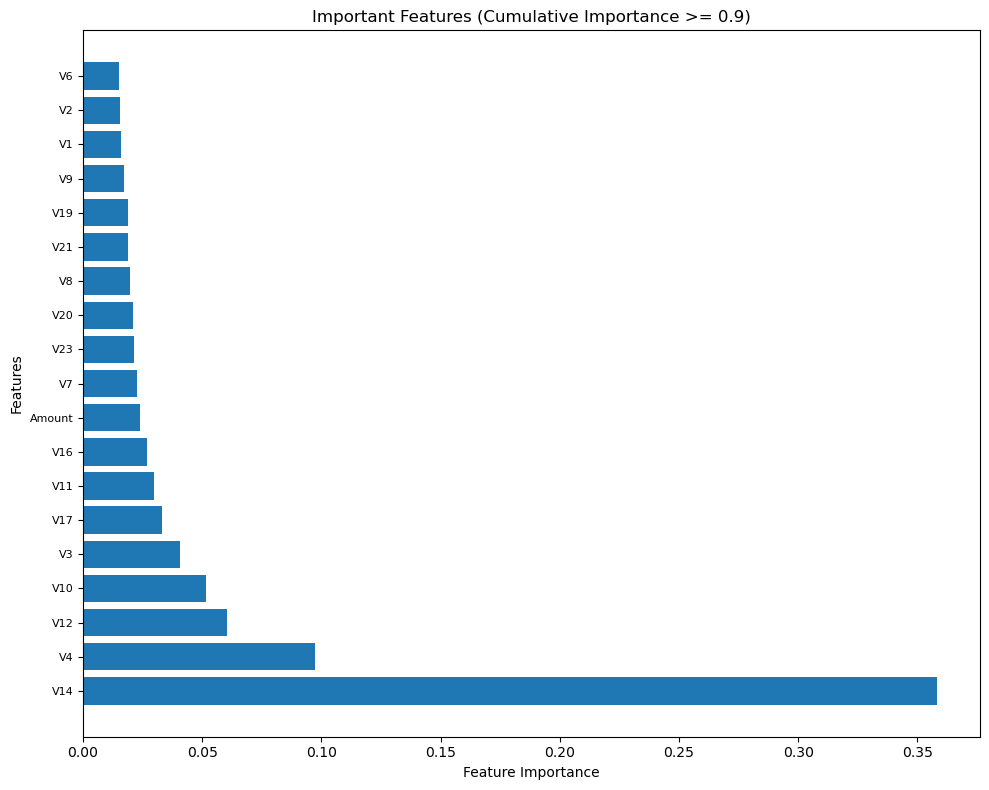

╒═══════════╤═══════════╕
│ Feature   │    Weight │
╞═══════════╪═══════════╡
│ V14       │ 0.39469   │
├───────────┼───────────┤
│ V4        │ 0.107182  │
├───────────┼───────────┤
│ V12       │ 0.0664243 │
├───────────┼───────────┤
│ V10       │ 0.0567306 │
├───────────┼───────────┤
│ V3        │ 0.0449438 │
├───────────┼───────────┤
│ V17       │ 0.0365719 │
├───────────┼───────────┤
│ V11       │ 0.0327165 │
├───────────┼───────────┤
│ V16       │ 0.0297422 │
├───────────┼───────────┤
│ Amount    │ 0.0261071 │
├───────────┼───────────┤
│ V7        │ 0.0251157 │
├───────────┼───────────┤
│ V23       │ 0.0236836 │
├───────────┼───────────┤
│ V20       │ 0.0231328 │
├───────────┼───────────┤
│ V8        │ 0.0217008 │
├───────────┼───────────┤
│ V21       │ 0.0205993 │
├───────────┼───────────┤
│ V19       │ 0.0205993 │
├───────────┼───────────┤
│ V9        │ 0.0189469 │
├───────────┼───────────┤
│ V1        │ 0.0175149 │
├───────────┼───────────┤
│ V2        │ 0.0169641 │
├───────────

In [35]:
from tabulate import tabulate
# Step 10: Visualize the selected features
plt.figure(figsize=(10, 8))
plt.barh(range(len(important_features)), sorted_scores[:index+1], align='center')
plt.yticks(range(len(important_features)), important_features, fontsize=8)
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title('Important Features (Cumulative Importance >= 0.9)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 11: Display the selected features and their weights in a table
important_scores = sorted_scores[:index+1]
total_importance = np.sum(important_scores)
weights = important_scores / total_importance

table_data = [[feature, weight] for feature, weight in zip(important_features, weights)]
headers = ["Feature", "Weight"]

# Print the table
table_str = tabulate(table_data, headers, tablefmt="fancy_grid")
print(table_str)

# Save the table as a PDF
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.savefig("feature_importance_table.pdf", bbox_inches="tight")

# GridSearch application

In [36]:
from sklearn.model_selection import GridSearchCV
# Define Parameter Grids for GridSearchCV
param_grid_dt = {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_et = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
param_grid_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}

In [37]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')
# Train and Tune Models
def grid_search(model, param_grid, name):
    grid = GridSearchCV(model, param_grid, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], refit='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid.best_params_}")
    return grid.best_estimator_


best_dt = grid_search(DecisionTreeClassifier(criterion='entropy', random_state=42), param_grid_dt, "Decision Tree")
best_rf = grid_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")
best_et = grid_search(ExtraTreesClassifier(random_state=42), param_grid_et, "Extra Trees")
best_xgb = grid_search(XGBClassifier(n_estimators=50, eval_metric='logloss'), param_grid_xgb, "XGBoost")
best_ada = grid_search(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, algorithm='SAMME'), param_grid_ada, "AdaBoost")

Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_split': 10}
Best parameters for Random Forest: {'max_depth': 10, 'n_estimators': 100}
Best parameters for Extra Trees: {'max_depth': 10, 'n_estimators': 100}
Best parameters for XGBoost: {'learning_rate': 0.2, 'n_estimators': 100}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorith

Best parameters for AdaBoost: {'learning_rate': 0.1, 'n_estimators': 100}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


# Voting for best results

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

# Step 1: Store Predictions for Meta-Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_features_train = np.zeros((X_train.shape[0], 5))  # 5 models
meta_features_test = np.zeros((X_test.shape[0], 5))

# Base models
base_models = [
    ('dt', best_dt),
    ('rf', best_rf),
    ('et', best_et),
    ('xgb', best_xgb),
    ('ada', best_ada)
]
y_train = y_train.to_numpy()  # Convert to NumPy array

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    #y_tr, y_val = y_train[train_idx], y_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]


    
    # Train base models and store predictions for meta-model
    for i, (name, model) in enumerate(base_models):
        model.fit(X_tr, y_tr)
        meta_features_train[val_idx, i] = model.predict_proba(X_val)[:, 1]  # Use probabilities

# Fit final models on full training data to predict test meta-features
for i, (name, model) in enumerate(base_models):
    model.fit(X_train, y_train)
    meta_features_test[:, i] = model.predict_proba(X_test)[:, 1]

# Step 2: Define and Tune Voting Classifier with GridSearchCV
voting_clf = VotingClassifier(estimators=base_models, voting='soft')

# Tune Voting Weights Using GridSearchCV
param_grid_voting = {
    'weights': [
        (1, 1, 1, 1, 1),
        (1, 2, 2, 3, 1),
        (2, 1, 1, 1, 2),
        (3, 2, 1, 2, 1),
        (1, 1, 2, 2, 3)
    ]
}

grid_voting = GridSearchCV(voting_clf, param_grid_voting, cv=5, scoring='accuracy', n_jobs=-1)
grid_voting.fit(meta_features_train, y_train)  # Use meta-features for fitting

# Best Voting Classifier with Optimized Weights
best_voting = grid_voting.best_estimator_
print(f"Best Voting Weights: {grid_voting.best_params_}")


# Second Stage : LSTM predictions

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense

# Step 3: LSTM Meta-Learner on top of Voting Classifier Predictions
best_voting.fit(X_train, y_train)

# Get Predictions from Voting Classifier (probabilities)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities of class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities of class 1

# Reshape for LSTM (required shape: [samples, time_steps, features])
X_train_lstm = y_pred_voting_train.reshape(-1, 1, 1)  # Shape (samples, 1, 1)
X_test_lstm = y_pred_voting_test.reshape(-1, 1, 1)  # Shape (samples, 1, 1)

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Check the shape of the labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

lstm_model = Sequential([
    LSTM(64, return_sequences=False),  # Set return_sequences to False
    Dropout(0.2),
    Dense(2, activation='softmax')  # Two neurons for two classes
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the LSTM Meta-Learner
lstm_model.fit(X_train_lstm, y_train_cat, epochs=20, batch_size=16, validation_data=(X_test_lstm, y_test_cat))


# Step 4: Evaluate LSTM Meta-Learner
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm_labels = np.argmax(y_pred_lstm, axis=1)

# Calculate accuracy of LSTM Meta-Learner
final_accuracy = accuracy_score(y_test, y_pred_lstm_labels)
print("Final LSTM Meta-Learner Accuracy:", final_accuracy)

# Final performance results

In [ ]:
# Store results
results = []

# Now evaluate the metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, cohen_kappa_score, matthews_corrcoef, roc_auc_score
y_proba_lstm = y_pred_lstm[:, 1]  # Extract probability of class 1
# Check the shape of y_pred_lstm
#print("Shape of y_pred_lstm:", y_pred_lstm.shape)
metrics_lstm = [
    "LSTM",
    accuracy_score(y_test, y_pred_lstm_labels),
    precision_score(y_test, y_pred_lstm_labels),
    recall_score(y_test, y_pred_lstm_labels),
    f1_score(y_test, y_pred_lstm_labels),
    fbeta_score(y_test, y_pred_lstm_labels, beta=2),
    cohen_kappa_score(y_test, y_pred_lstm_labels),
    matthews_corrcoef(y_test, y_pred_lstm_labels),
    roc_auc_score(y_test, y_proba_lstm)  # Use probabilities for ROC AUC
]
#print(metrics_lstm)
results.append(metrics_lstm)

In [ ]:
print("Classification report:")
print(classification_report(y_test, y_pred_lstm_labels))
print("Confusion matrix:")

print(confusion_matrix(y_test, y_pred_lstm_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_labels))
print("Pricision:", precision_score(y_test, y_pred_lstm_labels))
print("Recall:",recall_score(y_test, y_pred_lstm_labels))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lstm))
print("F1-Score:", f1_score(y_test, y_pred_lstm_labels))
# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_labels, beta=2)
print("F2-Score:", f2)
print("Cohen's Kappa Score:", cohen_kappa_score(y_test, y_pred_lstm_labels))
print("Matthews Correlation Coefficient (MCC):", matthews_corrcoef(y_test, y_pred_lstm_labels))
# Calculer l'AUC
auc_score = roc_auc_score(y_test, y_proba_lstm)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Add autoencoders

In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# Define the Autoencoder
input_shape = (X_train_lstm.shape[1],)  # Adjust input shape based on your data
input_layer = Input(shape=input_shape)

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(128, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(input_shape[0], activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the Autoencoder
autoencoder.fit(X_train_lstm, X_train_lstm,
                epochs=50,
                batch_size=32,
                validation_data=(X_test_lstm, X_test_lstm))

# Print model summary
autoencoder.summary()

# Step 3: Create an Encoder Model for Feature Extraction
encoder = Model(input_layer, encoded)

# Step 4: LSTM Meta-Learner on top of the encoded features
# (Assuming best_voting is a previously trained ensemble model)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Get the encoded representations (compressed features) for both train and test data
X_train_encoded = encoder.predict(X_train_lstm)
X_test_encoded = encoder.predict(X_test_lstm)

# Check the shape of the categorical labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)


In [ ]:
X_train_encoded = X_train_encoded[:y_train_cat.shape[0]]
X_test_encoded = X_test_encoded[:y_test_cat.shape[0]]
#print("X_train_encoded shape:", X_train_encoded.shape)
#print("y_train_cat shape:", y_train_cat.shape)
#print("X_test_encoded shape:", X_test_encoded.shape
# Ensure the shape is (samples, time_steps, features) for LSTM
X_train_lstm_ae = X_train_encoded.reshape(X_train_encoded.shape[0], 1, -1)
X_test_lstm_ae = X_test_encoded.reshape(X_test_encoded.shape[0], 1, -1)


In [ ]:
#print("X_train_lstm_ae shape:", X_train_lstm_ae.shape)
#print("y_train_cat shape:", y_train_cat.shape)
#print("X_test_lstm_ae shape:", X_test_lstm_ae.shape)
#print("y_test_cat shape:", y_test_cat.shape)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Recall

# Early stopping to monitor validation loss
#early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# LSTM Model
lstm_model = Sequential([
    #Input(shape=(X_train_lstm_ae.shape[1], X_train_lstm_ae.shape[2])),
    # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Now fit the LSTM Meta-Learner on the reshaped encoded data
history = lstm_model.fit(X_train_lstm_ae, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm_ae, y_test_cat))#, callbacks=[early_stop], verbose=1)

In [ ]:
# LSTM without Autoencoder Model
lstm_model_raw = Sequential([
    #Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    
   # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model_raw.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Train the LSTM Meta-Learner
history_raw = lstm_model_raw.fit(X_train_lstm, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm, y_test_cat))#, callbacks=[early_stop], verbose=1)
y_pred_lstm_raw = lstm_model_raw.predict(X_test_lstm)
accuracy_raw = accuracy_score(y_test, np.argmax(y_pred_lstm_raw, axis=1))

In [ ]:
# Step 5: Evaluate LSTM Meta-Learner
y_pred_lstm_ae = lstm_model.predict(X_test_lstm_ae)
y_pred_lstm_ae_labels = np.argmax(y_pred_lstm_ae, axis=1)

# Calculate accuracy of LSTM Meta-Learner
final_accuracy = accuracy_score(y_test, y_pred_lstm_ae_labels)
#print("Final LSTM Meta-Learner Accuracy:", final_accuracy)

In [ ]:
print("Accuracy without Autoencoder:", accuracy_raw)
print("Accuracy with Autoencoder:", final_accuracy)

In [ ]:
print("Performance without Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_labels))
#print("Confusion matrix:")
cm1 = confusion_matrix(y_test, y_pred_lstm_labels)

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)

# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
print("Performance with Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_ae_labels))
#print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred_lstm_ae_labels)
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_ae_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_ae_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_ae_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_ae_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_ae_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_ae_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_ae_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_ae_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)

# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_ae_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_ae_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Sauvegarde du modèle avec pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(lstm_model, f)

In [ ]:
# Extract loss values
train_loss = history.history['loss']  # Training loss for each epoch
val_loss = history.history['val_loss']  # Validation loss for each epoch (if validation data is provided)

train_loss2 = history_raw.history['loss']
val_loss2 = history_raw.history['val_loss']

# Plotting the loss curves for both models
plt.figure(figsize=(10, 6))

# Plot for Model 1
plt.plot(train_loss, label='With Autoencoder - Training Loss', color='blue')
plt.plot(val_loss, label='With Autoencoder - Validation Loss', color='orange')

# Plot for Model 2
plt.plot(train_loss2, label='Without Autoencoder - Training Loss', color='green')
plt.plot(val_loss2, label='Without Autoencoder - Validation Loss', color='red')

# Adding labels and title
plt.title('LSTM Model Loss vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

In [ ]:
train_acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

train_acc2 = history_raw.history['accuracy']
val_acc2 = history_raw.history['val_accuracy']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_acc1, label='With Autoencoder - Training Accuracy', color='blue')
plt.plot(val_acc1, label='With Autoencoder - Validation Accuracy', color='orange')

plt.plot(train_acc2, label='Without Autoencoder - Training Accuracy', color='green')
plt.plot(val_acc2, label='Without Autoencoder - Validation Accuracy', color='red')


plt.title('LSTM Model Accuracy vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
train_recall1 = history.history['recall']
val_recall1 = history.history['val_recall']

train_recall2 = history_raw.history['recall_1']
val_recall2 = history_raw.history['val_recall_1']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_recall1, label='With Autoencoder - Training Racall', color='blue')
plt.plot(val_recall1, label='With Autoencoder - Validation Recall', color='orange')

plt.plot(train_recall2, label='Without Autoencoder - Training Recall', color='green')
plt.plot(val_recall2, label='Without Autoencoder - Validation Recall', color='red')


plt.title('LSTM Model Racall vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()

In [ ]:
print("Confusion matrix with autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
print("Confusion matrix without autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()